# Decision Tree
Dataset - [Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

# 🌳 Machine Learning: Decision Trees (Шешім ағаштары)

Шешім ағашы — бұл деректерді белгілі бір ережелер (сұрақтар) жиынтығы арқылы иерархиялық құрылымға бөлетін алгоритм. Ол әрі **Классификация**, әрі **Регрессия** есептері үшін қолданылады.

---

### 📋 Негізгі терминология
* **Root Node (Түпкі түйін):** Ағаштың ең басы, бүкіл датасет осы жерден бастап бөлінеді.
* **Decision Node (Шешім түйіні):** Деректерді одан әрі тармақтайтын ішкі түйін.
* **Leaf Node (Жапырақ):** Соңғы шешім қабылданатын нүкте. Бұдан ары бөліну болмайды.
* **Pruning (Бұтау):** Ағаштың тым тереңдеп кетпеуі үшін артық бұтақтарды кесу.

---

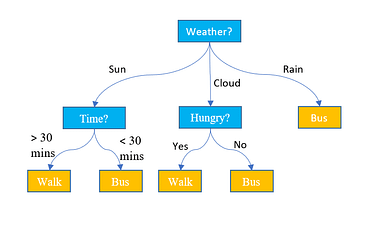

### 🧬 Математикалық негізі: Деректерді қалай бөлеміз?

Ағаш деректерді бөлгенде "ең таза" (pure) топтарды алғысы келеді. Ол үшін келесі көрсеткіштер қолданылады:

#### 1. Entropy (Энтропия)
Деректердегі хаос немесе белгісіздік деңгейі. Егер топтағы деректер әртүрлі болса, энтропия жоғары болады.
$$E(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$
*Мұндағы $p_i$ — $i$-ші кластың үлесі.*

#### 2. Information Gain (Ақпараттық өсім)
Бөлінуден кейін энтропияның қаншалықты азайғанын көрсетеді. Алгоритм осы көрсеткіш ең жоғары болатын белгіні (feature) таңдайды.
$$IG(S, A) = E(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} E(S_v)$$

#### 3. Gini Impurity (Джини көрсеткіші)
Scikit-learn кітапханасында әдепкі бойынша (default) қолданылады. Бұл — кездейсоқ таңдалған элементтің қате классификациялану ықтималдығы.
$$Gini = 1 - \sum_{i=1}^{n} (p_i)^2$$

---

### 🚢 Titanic Dataset-ке қолдану мысалы

Титаник деректер жиынтығында шешім ағашы келесі сұрақтар тізбегін құруы мүмкін:
1.  **Сұрақ:** Жынысы ер адам ба? 👨
    * *Иә:* Тірі қалу ықтималдығы төмен (Келесі сұрақ: Жасы 10-нан кіші ме?).
    * *Жоқ:* Тірі қалу ықтималдығы жоғары (Келесі сұрақ: Билет класы 1-ші ме?).

---

### ⚠️ Overfitting (Қайта оқыту) мәселесі

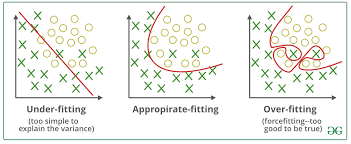

Шешім ағаштары өте "пысық". Егер оны шектемесеңіз, ол әрбір деректі жеке-жеке жаттап алғанша бөліне береді. Бұл жағдайда модель жаттығу деректерінде 100% нәтиже бергенімен, жаңа деректерде қателеседі.

**Шешімі — Гиперпараметрлерді баптау:**
* `max_depth`: Ағаштың ең жоғарғы тереңдігі (мысалы, 3 немесе 5).
* `min_samples_split`: Түйінді бөлу үшін қажетті ең аз үлгілер саны.
* `min_samples_leaf`: Жапырақта қалуы тиіс ең аз үлгілер саны.

---

### ✅ Артықшылықтары мен Кемшіліктері

| Артықшылығы | Кемшілігі |
| :--- | :--- |
| Түсінуге және визуализациялауға оңай. | Оңай Overfitting-ке ұшырайды. |
| Деректерді нормализациялауды (scaling) қажет етпейді. | Деректердегі азғантай өзгеріс ағаш құрылымын қатты өзгертуі мүмкін (тұрақсыздық). |
| Категориялық және сандық деректермен жұмыс істейді. | "Сызықтық" тәуелділіктерді болжауға қиындық тудырады. |

---

### 💡 Есте сақтауға кеңес:
Шешім ағашын **"Көріпкел емес, логик"** деп елестетіңіз. Ол интуицияға емес, тек қатаң "Иә/Жоқ" шекараларына сүйенеді. Сондықтан ағаштың тым тармақталып, "орман ішінде адасып" кетпеуін қадағалау — дата сайентистің басты міндеті.

# 💻 Практикалық шпаргалка: Decision Tree Classifier

Шешім ағаштарын Python-да құру үшін негізінен `scikit-learn` кітапханасы қолданылады.

### ⚙️ Негізгі Гиперпараметрлер (`DecisionTreeClassifier`)

Модельді құру кезінде `Overfitting` (қайта оқыту) болдырмау үшін осы параметрлерді дұрыс баптау өте маңызды:

* **`criterion`** *(default="gini")*: Бөліну сапасын өлшейтін функция.
  * `"gini"` — Джини көрсеткіші (жылдам әрі жиі қолданылады).
  * `"entropy"` — Ақпараттық өсім (Information Gain).
* **`max_depth`** *(default=None)*: Ағаштың максималды тереңдігі (қабаттар саны). Егер `None` болса, жапырақтар толық тазарғанша өсе береді (Overfitting қаупі жоғары!). Әдетте `3`, `5` немесе `10` деп шектейді.
* **`min_samples_split`** *(default=2)*: Түйінді одан әрі екіге бөлу үшін сол түйінде кемінде қанша үлгі (қатар) болуы керектігін көрсетеді.
* **`min_samples_leaf`** *(default=1)*: Соңғы жапырақта (leaf) қалуы тиіс ең аз үлгілер саны. Осы параметрді көбейту арқылы модельді қарапайым ете аласыз.
* **`random_state`** *(int)*: Кодты әр орындаған сайын кездейсоқ бөлінулер бірдей болуы үшін қолданылады (мысалы, `random_state=42`).

---

### 🚀 Толық код мысалы (Iris датасетімен)

Бұл кодты Colab-тың код ұяшығына (Code cell) қойып, тікелей орындай аласыз. Ол датасетті жүктейді, модельді оқытады және ағашты салып береді.

```python
# 1. Қажетті кітапханаларды шақыру
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 2. Деректерді жүктеу (Iris датасеті)
iris = load_iris()
X = iris.data    # Белгілер (жапырақ өлшемдері)
y = iris.target  # Нысаналы айнымалы (гүл түрлері)

# 3. Деректерді жаттығу (80%) және тест (20%) жиынтықтарына бөлу
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Модельді инициализациялау (Параметрлерді осы жерде береміз)
tree_model = DecisionTreeClassifier(
    criterion='entropy',     # Энтропияны қолданамыз
    max_depth=3,             # Ағаш 3 қабаттан аспауы керек
    min_samples_split=4,     # Бөліну үшін кемінде 4 үлгі болуы керек
    random_state=42          # Нәтиже тұрақты болуы үшін
)

# 5. Модельді оқыту (Training)
tree_model.fit(X_train, y_train)

# 6. Тест деректеріне болжам жасау
y_pred = tree_model.predict(X_test)

# 7. Модельдің дәлдігін тексеру
accuracy = accuracy_score(y_test, y_pred)
print(f"Модельдің дәлдігі (Accuracy): {accuracy * 100:.2f}%")

# 8. Шешім ағашын визуализациялау
plt.figure(figsize=(12, 8))
plot_tree(tree_model,
          feature_names=iris.feature_names,  
          class_names=iris.target_names,
          filled=True,      # Түйіндерді бояу
          rounded=True)     # Бұрыштарды дөңгелету
plt.title("Iris датасетіне құрылған Шешім Ағашы")
plt.show()

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [4]:
# Деректерді жүктеу
data = pd.read_csv("/content/Titanic-Dataset.csv")

# Есімдер бағанын өшіреміз
data = data.drop("Name", axis=1)
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data.shape

(891, 11)

In [6]:
data.info()  # Бос орындар бар екен солармен жұмыс жасаймыз

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [7]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='Age'>

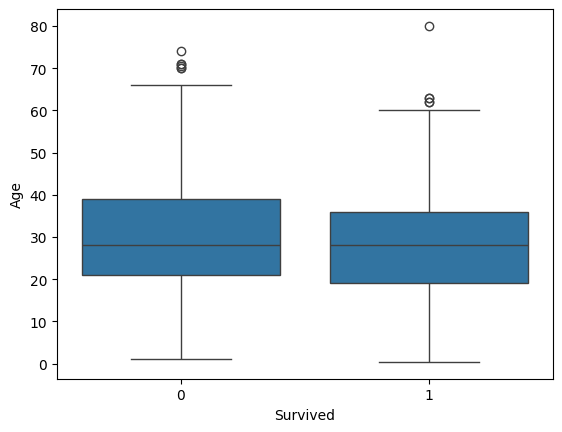

In [11]:
sns.boxplot(x="Survived", y="Age", data=data)
# Жас пен тірі қалу арасындағы байланыс

In [15]:
# Бізде медиана мен орта көрсеткіш тым алшақ болмаған соң, бос орынды орта жаспен толтырамыз
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Age'].isnull().sum()

np.int64(0)

In [16]:
# Кабина бағаны бізге керек па?
data['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [19]:
# Cabin, Ticket бағандары біздің жағдайымызда оны анализге тым көп уақыт керек,
# және бір пайдалы ақпарат болары анық емес, сондықтан өшіреміз
data = data.drop(['Cabin', 'Ticket'], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [20]:
# Бұл баған жай реттік нөмер
data = data.drop('PassengerId', axis=1)

In [28]:
# Embarked бағанындағы саны жағынан ең көп классты бос орындарға толтырамыз
groups = data.groupby('Embarked')['Embarked'].count()
max_emb = max(groups.items(), key=lambda x: x[1])[0]
data['Embarked'].fillna(max_emb, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


/tmp/ipython-input-395/1559557453.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna(max_emb, inplace=True)


In [29]:
# Sex, Embarked бағандарын санға түрлендіреміз - LabelEncoder
label_encoder = LabelEncoder()
data['Sex'] = label_encoder.fit_transform(data['Sex'])
data['Embarked'] = label_encoder.fit_transform(data['Embarked'])
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


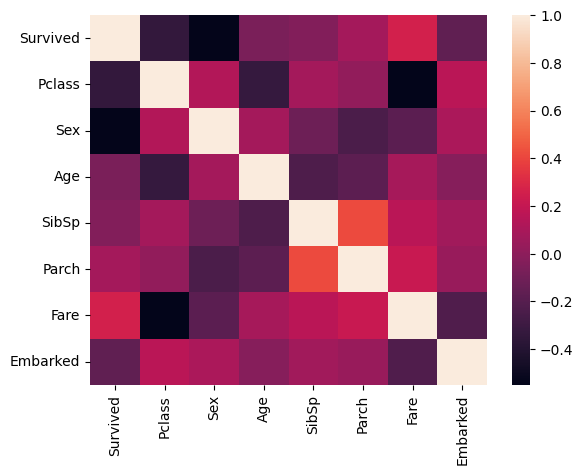

In [30]:
sns.heatmap(data.corr())
plt.show()

In [34]:
scaler = StandardScaler()
data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,-0.592481,1,0,-0.502445,2
1,1,1,0,0.638789,1,0,0.786845,0
2,1,3,0,-0.284663,0,0,-0.488854,2
3,1,1,0,0.407926,1,0,0.420730,2
4,0,3,1,0.407926,0,0,-0.486337,2


In [36]:
# Деректерді бөлеміз
X, y = data.drop('Survived', axis=1), data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [37]:
# Ағаш моделін құрастырамыз
tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    min_samples_split=4,
    random_state=42
)

In [38]:
# модельді оқытамыз
tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_split=4,
                       random_state=42)

In [40]:
# Тест деректеріне болжам жасау
y_pred = tree.predict(X_test)

# Модельдің дәлдігін тексеру
accuracy = accuracy_score(y_test, y_pred)
print(f"Модельдің дәлдігі (Accuracy): {accuracy * 100:.2f}%")

Модельдің дәлдігі (Accuracy): 79.89%


In [46]:
feature_names = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked']

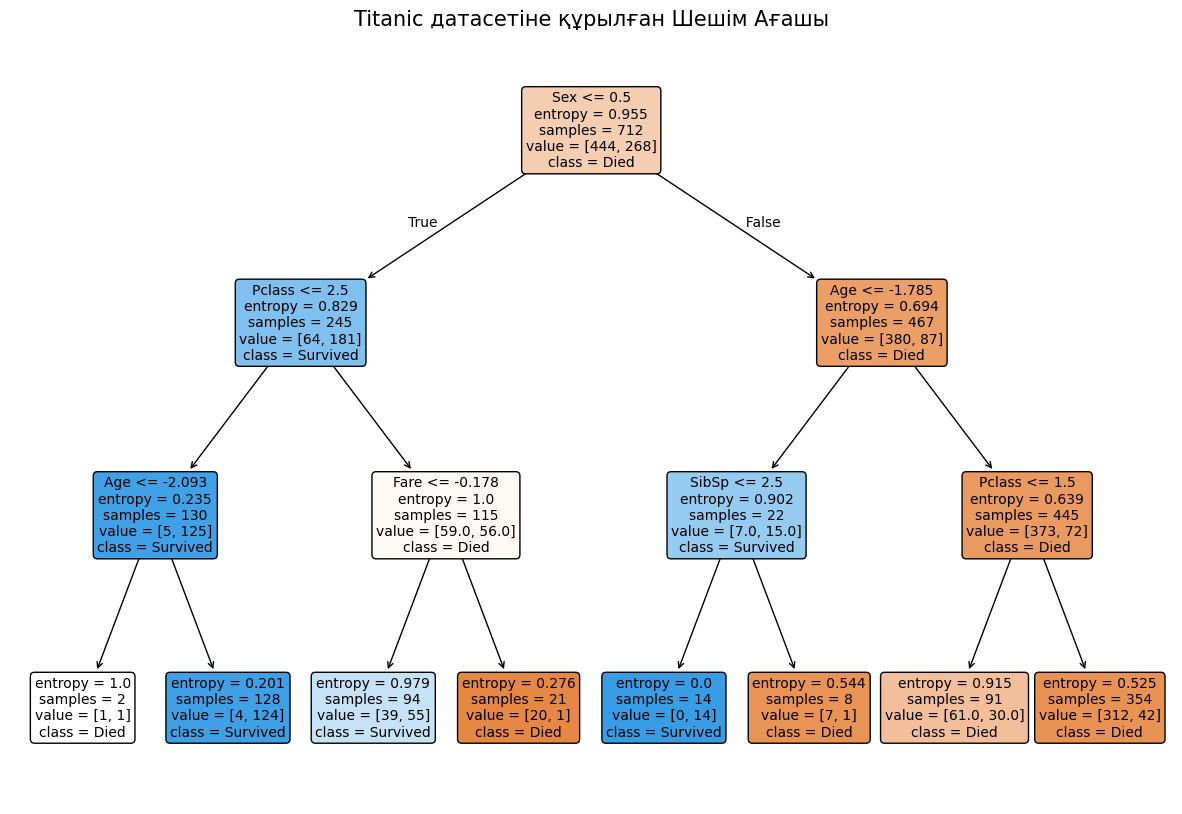

In [55]:
# Шешім ағашын визуализациялау
plt.figure(figsize=(15, 10)) # Ағаш жақсы көрінуі үшін өлшемді үлкейттік

plot_tree(tree,
          # feature_names: Модельді оқытуға қолданылған бағандар тізімі
          feature_names=X.columns,
          # class_names: Мәтіндік форматта (0 - Died, 1 - Survived)
          class_names=['Died', 'Survived'],
          filled=True,      # Түйіндерді класқа байланысты бояу
          rounded=True,     # Бұрыштарды дөңгелету
          fontsize=10)      # Жазулар анық көрінуі үшін

plt.title("Titanic датасетіне құрылған Шешім Ағашы", fontsize=15)

plt.savefig('titanic_tree.png')

/tmp/ipython-input-395/1405168257.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


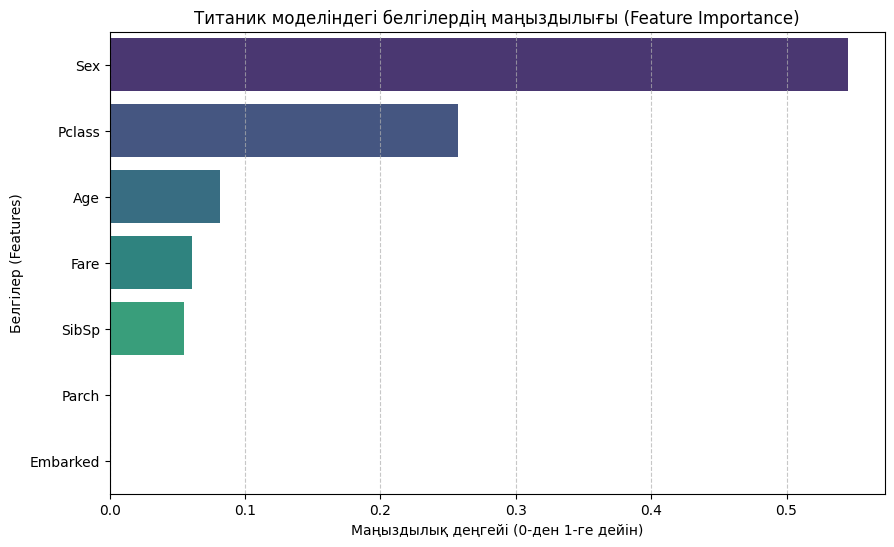

Белгілердің нақты көрсеткіштері:
    Feature  Importance
1       Sex    0.545336
0    Pclass    0.257549
2       Age    0.081106
5      Fare    0.060874
3     SibSp    0.055136
4     Parch    0.000000
6  Embarked    0.000000


In [56]:

# 1. Модельден маңыздылық көрсеткіштерін алу
importances = tree.feature_importances_
feature_names = X.columns # Оқытуға қатысқан бағандардың аты

# 2. Деректерді ыңғайлы болу үшін DataFrame-ге жинау және реттеу (Sorting)
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Визуализация (График түрінде шығару)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Титаник моделіндегі белгілердің маңыздылығы (Feature Importance)')
plt.xlabel('Маңыздылық деңгейі (0-ден 1-ге дейін)')
plt.ylabel('Белгілер (Features)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('important_features.png')
plt.show()

# Текст түрінде нәтижені шығару
print("Белгілердің нақты көрсеткіштері:")
print(feature_importance_df)

# 📊 Titanic Model: Қорытынды және Талдау

Бұл бөлімде **Decision Tree Classifier** моделінің Титаник датасетіндегі жұмыс нәтижелері жинақталған.

---

### 🎯 Негізгі көрсеткіш: Accuracy (Дәлдік)
Модельдің тест деректеріндегі көрсеткіші: **79%**.

* **Мағынасы:** Модель 100 жолаушының 79-ының тағдырын (тірі қалғанын немесе қайтыс болғанын) қатесіз болжай алды.
* **Салыстырмалы талдау:** Бұл көрсеткіш базалық болжамдардан (мысалы, "барлық әйелдер аман қалды" деген ережеден) жоғары, бұл модельдің деректердегі жасырын заңдылықтарды таба алғанын білдіреді.

---

### 🔍 Модельдің күшті және әлсіз жақтары

| Артықшылығы | Кемшілігі |
| :--- | :--- |
| **Интерпретация:** Ағаш құрылымы арқылы шешімнің қалай қабылданғанын көруге болады. | **Шектеулі дәлдік:** Жалғыз ағаш күрделірек байланыстарды (мысалы, отбасы мүшелерінің саны) толық қамти алмайды. |
| **Жылдамдық:** Модель өте жылдам оқытылады және болжам жасайды. | **Тұрақсыздық:** Деректердегі азғантай шу немесе өзгеріс ағаштың құрылымын өзгертіп жіберуі мүмкін. |

---

### 🧬 Feature Importance (Белгілердің маңыздылығы)
Талдау нәтижесі бойынша модель шешім қабылдағанда келесі бағандарға ең көп сүйенді:
1.  **Sex (Жынысы):** Ең басты фактор.
2.  **Pclass (Билет класы):** Әлеуметтік жағдайдың әсері.
3.  **Age (Жасы):** "Балалар мен әйелдерге бірінші кезекте" принципінің көрінісі.

---

### 🚀 Болашақтағы даму қадамдары (Next Steps)

Дәлдікті 80-85%-ға дейін жеткізу үшін келесі әдістерді қолдану ұсынылады:

1.  **Hyperparameter Tuning:** `GridSearchCV` арқылы `max_depth` және `min_samples_split` параметрлерінің ең тиімді комбинациясын табу.
2.  **Random Forest:** Бірнеше ағаштың ансамблін құру арқылы қателікті азайту (Overfitting-ке төзімдірек).
3.  **Feature Engineering:** Есімдерден (Names) титулдарды (Mr, Mrs, Master) бөліп алу және отбасы мүшелерінің санын қосу.

# 🔍 GridSearchCV: Гиперпараметрлерді автоматты таңдау

Модельдің параметрлерін қолмен өзгертпес үшін, **GridSearchCV** (Grid Search Cross-Validation) әдісін қолданамыз. Ол біз көрсеткен барлық комбинацияларды тексеріп, ең жоғары нәтиже бергенін таңдайды.

### ⚙️ GridSearchCV қалай жұмыс істейді?

Ол екі процесті біріктіреді:
1.  **Grid Search:** Параметрлердің "торын" (сетка) жасап, барлық нұсқаны тексеру.
2.  **Cross-Validation (CV):** Деректерді бірнеше бөлікке (folds) бөліп, әрқайсысында тексеру арқылы нәтиженің тұрақтылығын қамтамасыз ету.

Жалпы тексерілетін модельдер саны:
$$Total = (параметрлер\,комбинациясы) \times CV$$

---

### 🚀 Титаник моделіне арналған код (Мысал)

Бұл кодты алдыңғы модельден кейін қосып, ең жақсы параметрлерді таба аласыз:

```python
from sklearn.model_selection import GridSearchCV

# 1. Тексергіміз келетін параметрлердің "торын" (grid) жасаймыз
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. GridSearchCV объектісін құру
# cv=5 дегеніміз - деректерді 5 бөлікке бөліп тексеру
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 # Барлық процессор ядроларын қолдану (жылдамдату үшін)
)

# 3. Модельді оқыту (іздеу процесі)
grid_search.fit(X_train, y_train)

# 4. Ең жақсы параметрлерді шығару
print("Ең жақсы параметрлер:", grid_search.best_params_)
print(f"Ең үздік CV дәлдігі: {grid_search.best_score_ * 100:.2f}%")

# 5. Ең үздік модельді қолдану
best_tree = grid_search.best_estimator_
y_pred_best = best_tree.predict(X_test)
print(f"Тест деректеріндегі соңғы дәлдік: {accuracy_score(y_test, y_pred_best) * 100:.2f}%")

In [58]:
import joblib

joblib.dump(tree, 'titanic_model.joblib')
print("Модель сәтті сақталды!")

Модель сәтті сақталды!
